In [1]:
import torch
import torch.nn as nn
x = torch.rand(5, 3)
print(x)

tensor([[0.8913, 0.6851, 0.4317],
        [0.8546, 0.6960, 0.1398],
        [0.0064, 0.8238, 0.2373],
        [0.5549, 0.4548, 0.7372],
        [0.0251, 0.2738, 0.2972]])


In [2]:
print(torch.cuda.is_available())  
print(torch.cuda.get_device_name(0))
device = torch.device("cuda")
x = torch.randn(1, 3, dtype=float).to(device)
y = torch.randn(3, 1, dtype=float, device=device)
print(x.shape) 
print(x.dtype)
print(x)
print(y.shape) 
print(y.dtype)
print(y)

True
Tesla T4
torch.Size([1, 3])
torch.float64
tensor([[-1.1241, -0.5304, -1.0357]], device='cuda:0', dtype=torch.float64)
torch.Size([3, 1])
torch.float64
tensor([[-0.7048],
        [ 0.7076],
        [-0.3212]], device='cuda:0', dtype=torch.float64)


In [3]:
a = torch.randn(3, 3).to(device)
print(a.dtype)  # should be float32

# Explicit cast
b = a.to(torch.float16)
print(b.dtype)  # float16 - this is what LLMs run in
print(torch.cuda.memory_allocated() / 1024**2, "MB")

torch.float32
torch.float16
0.001953125 MB


In [4]:
def multiply(a, b):
    return a @ b

print(multiply(x, y))

tensor([[0.7495]], device='cuda:0', dtype=torch.float64)


In [5]:
x = torch.randn(4, device='cuda')
y = torch.randn(4, device='cuda')
print(multiply(x, y))        # dot product - should be scalar
print(multiply(x, y).shape)  # what shape is it?

A = torch.randn(3, 4, device='cuda')
print(multiply(A, x))        # matrix-vector - should be shape (3,)
print(multiply(A, x).shape)

tensor(2.0441, device='cuda:0')
torch.Size([])
tensor([ 2.1077, -1.2015,  2.5371], device='cuda:0')
torch.Size([3])


In [6]:
x = torch.tensor(4.0, requires_grad=True)
y = 3*x**2 + 2*x + 1

# what pytorch recorded - the last operation
print(y.grad_fn)

# one step back
print(y.grad_fn.next_functions)

# two steps back
print(y.grad_fn.next_functions[0][0].next_functions)

# three steps back
print(y.grad_fn.next_functions[0][0].next_functions[0][0].next_functions)

((<AddBackward0 object at 0x7be6f3336d70>, 0), (None, 0))
((<MulBackward0 object at 0x7be6f3336d70>, 0), (<MulBackward0 object at 0x7be6f2345450>, 0))
((<PowBackward0 object at 0x7be5ccb43b50>, 0), (None, 0))


In [7]:
y = x * x
print(y.grad_fn.next_functions)
# Output: ((<AccumulateGrad object at ...>, 0), (<AccumulateGrad object at ...>, 0))

((<AccumulateGrad object at 0x7be5ccbbad40>, 0), (<AccumulateGrad object at 0x7be5ccbbad40>, 0))


In [8]:
X = torch.randn(100, 1, device='cuda')
y = 2 * X + 3 + 0.1 * torch.randn(100, 1, device='cuda')

slope_weight = torch.randn(1, device="cuda", requires_grad=True)
bias_weight = torch.randn(1, device="cuda", requires_grad=True)

for step in range(100):
    
    prediction_values = slope_weight * X + bias_weight
    mse = ((prediction_values - y)**2).mean()
    if mse.item() < 0.1:
        print(f"converged at step {step}")
        break
    mse.backward()
    # print(mse)
    learning_rate = 0.3
    with torch.no_grad():
        w1 = (slope_weight.grad)
        w2 = (bias_weight.grad)
        slope_weight -= learning_rate*w1
        bias_weight -= learning_rate*w2
        slope_weight.grad.zero_()
        bias_weight.grad.zero_()
    # print(w1)
    # print(w2)
print(mse)
print(slope_weight)
print(bias_weight)

converged at step 2
tensor(0.0639, device='cuda:0', grad_fn=<MeanBackward0>)
tensor([1.7947], device='cuda:0', requires_grad=True)
tensor([2.9473], device='cuda:0', requires_grad=True)


In [9]:
X = torch.randn(100, 1, device='cuda')
y = 2 * X + 3 + 0.1 * torch.randn(100, 1, device='cuda')
linear_model = nn.Linear(1, 1, device="cuda")
learning_rate = 0.3
optimizer = torch.optim.SGD(params=linear_model.parameters(), lr=learning_rate)
for step in range(1000):
    loss = ((linear_model(X) - y)**2).mean()
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

print(f"Learned Slope (Weight): {linear_model.weight.item():.4f}")
print(f"Learned Intercept (Bias): {linear_model.bias.item():.4f}")

test_x = torch.tensor([[10.0]], device="cuda")
with torch.no_grad():
    prediction = linear_model(test_x)
    print(f"Prediction for x=10: {prediction.item():.4f}")

Learned Slope (Weight): 2.0090
Learned Intercept (Bias): 2.9960
Prediction for x=10: 23.0859


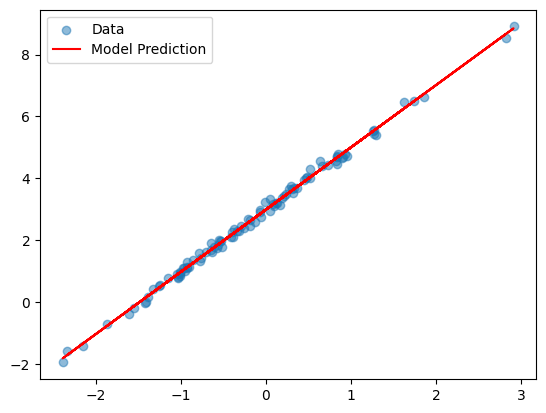

In [10]:
import matplotlib.pyplot as plt

# 1. Move to CPU and convert to NumPy
# .detach() is like saying "cut the umbilical cord to the graph"
X_cpu = X.cpu().numpy()
y_cpu = y.cpu().numpy()

with torch.no_grad():
    predictions_cpu = linear_model(X).cpu().numpy()

# 2. Plot the original "Noisy" dots
plt.scatter(X_cpu, y_cpu, label="Data", alpha=0.5)

# 3. Plot the "Learned" line
plt.plot(X_cpu, predictions_cpu, color='red', label="Model Prediction")
plt.legend()
plt.show()

In [11]:
import numpy as np

A = np.array([[1, 2],
              [3, 4]])

x1 = np.array([10, 20])          # shape (2,)
x2 = np.array([[10], [20]])      # shape (2,1)

out1 = A @ x1
out2 = A @ x2

print(out1, out1.shape)
print(out2, out2.shape)

[ 50 110] (2,)
[[ 50]
 [110]] (2, 1)


In [12]:
x1 = np.array([50, 110])       # shape (2,)
x2 = np.array([[50], [110]])   # shape (2,1)

print(x1[0])     # what do you get?
print(x2[0])     # what do you get?

50
[50]


In [13]:
tensorX = torch.randn(3, 2)
tensorY = torch.randn(2, 5)

vectorX = torch.randn(3)
vectorY = torch.randn(3)

batchX = torch.randn(6, 3, 2)
batchY = torch.randn(6, 2, 5)

queryM = torch.randn(5, 3, 5)
keyM = torch.randn(5, 3, 5)
#dot product
torch.einsum('i, i->', vectorX, vectorY)

#matrix multiply
torch.einsum('ij,jk->ik', tensorX, tensorY)

#batch matrix multiply
torch.einsum('bij, bjk -> bik', batchX, batchY)

#outer product
torch.einsum('i, j->ij', vectorX, vectorY)

#attention scores
torch.einsum('bij, bkj -> bik', queryM, keyM)

tensor([[[ 1.9369,  0.1917,  1.1930],
         [ 0.5315,  1.6519,  1.0634],
         [ 2.1778,  3.0945, -1.7630]],

        [[-0.2819,  2.2626, -0.6621],
         [ 2.4033,  1.9845, -2.9160],
         [ 7.6877, -3.3673, -1.9623]],

        [[ 1.2536,  0.4806,  0.7714],
         [ 0.2250, -1.0140,  0.5685],
         [ 0.3055,  0.4461, -3.1287]],

        [[ 1.3478, -1.0300, -0.4200],
         [ 2.2184, -0.6303,  1.2285],
         [ 2.3182, -2.3219, -2.0929]],

        [[-0.3590,  1.5993,  1.2787],
         [-4.7978, -8.1986, -5.9368],
         [-4.1858, -6.4765, -2.5409]]])

In [28]:
randTensorX = torch.randn(3, 2)
randTensorY = torch.randn(3, 1)

print(randTensorX.shape[0])
# torch.utils.data.dataset()

class RnadomDataSet(torch.utils.data.Dataset):
    def __init__(self, tensor1, tensor2):
        self.tensor1 = tensor1
        self.tensor2 = tensor2
    
    def __len__(self):
        return self.tensor1.shape[0]
    
    def __getitem__(self, index):
        return [self.tensor1[index], self.tensor2[index]]
    

3
